# C3 — Outlier Stress Test [Optional]

---

## 🔍 Problem-এ কী চাওয়া হয়েছে?

**C-Data-2**-এর `Income_BDT` column ব্যবহার করে:

$$\text{Income\_BDT} = [30000, 45000, 52000, \mathbf{300000}, 38000]$$

দুটো কাজ করতে হবে:

| Task | কী করতে হবে |
|---|---|
| **১** | **Min-Max Scaling** apply করা |
| **২** | **Robust Scaling** apply করা |
| **৩** | **এক লাইনে** তুলনা — 300000 outlier-কে দুটো method কীভাবে ভিন্নভাবে handle করে |

> এটি একটি **stress test** — outlier আছে এমন data-তে দুটো scaler-এর আচরণ পরীক্ষা করা।


---

## 🎯 এই কাজ থেকে আমরা কী অর্জন করতে পারব?

- 300000 outlier Min-Max ও Robust Scaling-এ **সংখ্যায় কতটা আলাদা প্রভাব ফেলে** দেখব।
- **Min-Max-এর দুর্বলতা** — outlier থাকলে বাকি সব মান কতটা compress হয় সেটা পাকাপাকিভাবে বুঝব।
- **Robust Scaler-এর শক্তি** — outlier থাকলেও normal মানগুলো কীভাবে protected থাকে দেখব।


---

## 🧠 কীভাবে চিন্তা করতে হবে?

### দুটো Scaler-এর Formula মনে করি:

**Min-Max:**
$$x' = \frac{x - x_{min}}{x_{max} - x_{min}}$$

এখানে $x_{max} = 300000$ (outlier!) → denominator বিশাল → বাকি সব মান ছোট।

**Robust:**
$$x' = \frac{x - \text{median}}{\text{IQR}}$$

Median ও IQR outlier-এ প্রভাবিত হয় না → বাকি মানগুলো ঠিকঠাক scale হয়।

### হাতের হিসাব (আগে থেকে চিন্তা করি):

**Min-Max:**
- $x_{min} = 30000$, $x_{max} = 300000$, range $= 270000$
- 30000 → $(30000-30000)/270000 = 0.000$
- 300000 → $(300000-30000)/270000 = 1.000$
- 52000 → $(52000-30000)/270000 = 0.081$ ← মাত্র 0.08!

**Robust:**
- Sorted: 30000, 38000, 45000, 52000, 300000
- median $= 45000$
- Q1 ≈ 34000, Q3 ≈ 176000 (sklearn interpolation), IQR ≈ 142000
- 30000 → $(30000-45000)/142000 ≈ -0.106$
- 52000 → $(52000-45000)/142000 ≈ 0.049$
- 300000 → $(300000-45000)/142000 ≈ 1.796$

বাকি মানগুলো (30K–52K) Min-Max-এ 0–0.08, Robust-এ −0.11 থেকে 0.05 — Robust-এ বেশি spread।


---

## 🛠️ Problem Solve করার Approach

**Step 1:** `Income_BDT` data তৈরি করা।

**Step 2:** Min-Max Scaling apply করা।

**Step 3:** Robust Scaling apply করা।

**Step 4:** দুটো পাশাপাশি তুলনা করা।

**Step 5:** এক লাইনে comparison statement।


## Step 1: Income_BDT Data তৈরি করা

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, RobustScaler

# Now we'll define the Income_BDT column from C-Data-2
income = np.array([30000, 45000, 52000, 300000, 38000], dtype=float)
df = pd.DataFrame({'Income_BDT': income})
# Here we've created a DataFrame with Income_BDT — 300000 is the clear outlier.

print("Income_BDT values:")
print(df.to_string(index=False))
print()
print(f"  Min    : {income.min():,.0f}")
print(f"  Max    : {income.max():,.0f}  ← outlier")
print(f"  Median : {np.median(income):,.0f}")
print(f"  Range  : {income.max() - income.min():,.0f}")


Income_BDT values:
 Income_BDT
    30000.0
    45000.0
    52000.0
   300000.0
    38000.0

  Min    : 30,000
  Max    : 300,000  ← outlier
  Median : 45,000
  Range  : 270,000


`dtype=float` → scaling-এ দশমিক সংখ্যা আসবে।
300000 outlier-এর কারণে range = 270000 — অথচ বাকি চারটি মান মাত্র 30000–52000।


## Step 2: Min-Max Scaling

In [11]:
# Now we'll apply Min-Max Scaling
mm = MinMaxScaler()
df['MinMax_Scaled'] = mm.fit_transform(df[['Income_BDT']]).flatten()
# Here we've scaled Income_BDT to [0, 1] using min=30000, max=300000.

print("Min-Max Scaling:")
print(f"  x_min = {mm.data_min_[0]:,.0f}")
print(f"  x_max = {mm.data_max_[0]:,.0f}  ← outlier controls this")
print(f"  range = {mm.data_max_[0] - mm.data_min_[0]:,.0f}")
print()
print(df[['Income_BDT', 'MinMax_Scaled']].to_string(index=False))


Min-Max Scaling:
  x_min = 30,000
  x_max = 300,000  ← outlier controls this
  range = 270,000

 Income_BDT  MinMax_Scaled
    30000.0       0.000000
    45000.0       0.055556
    52000.0       0.081481
   300000.0       1.000000
    38000.0       0.029630


`mm.data_min_[0]` ও `mm.data_max_[0]` → MinMaxScaler-এর শেখা min ও max।
300000 outlier `x_max` হওয়ায় range বিশাল — বাকি সব মান 0-এর কাছে চাপা পড়েছে।


## Step 3: Robust Scaling

In [4]:
# Now we'll apply Robust Scaling
rb = RobustScaler()
df['Robust_Scaled'] = rb.fit_transform(df[['Income_BDT']]).flatten()
# Here we've scaled Income_BDT using median and IQR — outlier-resistant.

print("Robust Scaling:")
print(f"  Median (center) = {rb.center_[0]:,.0f}")
print(f"  IQR    (scale)  = {rb.scale_[0]:,.0f}")
print()
print(df[['Income_BDT', 'Robust_Scaled']].to_string(index=False))


Robust Scaling:
  Median (center) = 45,000
  IQR    (scale)  = 14,000

 Income_BDT  Robust_Scaled
    30000.0      -1.071429
    45000.0       0.000000
    52000.0       0.500000
   300000.0      18.214286
    38000.0      -0.500000


`rb.center_[0]` → Robust Scaler-এর শেখা **median**।
`rb.scale_[0]` → Robust Scaler-এর শেখা **IQR**।
Median ও IQR outlier-এ টলে না — তাই 30K–52K মানগুলো ভালো ব্যবধান পেয়েছে।


## Step 4: পাশাপাশি তুলনা

In [5]:
# Now we'll build a side-by-side comparison table
comparison = df[['Income_BDT', 'MinMax_Scaled', 'Robust_Scaled']].copy()
comparison['Income_BDT'] = comparison['Income_BDT'].astype(int)
# Here we've assembled all three columns for clear comparison.

print("── Side-by-Side Comparison ──")
print(comparison.round(4).to_string(index=False))


── Side-by-Side Comparison ──
 Income_BDT  MinMax_Scaled  Robust_Scaled
      30000         0.0000        -1.0714
      45000         0.0556         0.0000
      52000         0.0815         0.5000
     300000         1.0000        18.2143
      38000         0.0296        -0.5000


Table-এ স্পষ্ট দেখা যাচ্ছে পার্থক্য।


In [14]:
# Now we'll compute the spread of non-outlier values in each scaler
non_outlier_mask = df['Income_BDT'] <= 52000

mm_non_out  = df.loc[non_outlier_mask, 'MinMax_Scaled']
rob_non_out = df.loc[non_outlier_mask, 'Robust_Scaled']

# Here we've isolated the 4 normal values (30K–52K) to measure their spread.
print("Normal values (30K–52K) spread after scaling:")
print(f"  Min-Max → range: {mm_non_out.min():.4f}  to  {mm_non_out.max():.4f}  (width = {mm_non_out.max()-mm_non_out.min():.4f})")
print(f"  Robust  → range: {rob_non_out.min():.4f}  to  {rob_non_out.max():.4f}  (width = {rob_non_out.max()-rob_non_out.min():.4f})")
print()

# Now we'll check where the outlier lands in each
print("Outlier (300000) scaled value:")
outlier_idx = df['Income_BDT'].idxmax()
print(f"  Min-Max → {df.loc[outlier_idx, 'MinMax_Scaled']:.4f}  (exactly 1.0 — it IS the max)")
print(f"  Robust  → {df.loc[outlier_idx, 'Robust_Scaled']:.4f}   (pushed far but normal data unaffected)")


Normal values (30K–52K) spread after scaling:
  Min-Max → range: 0.0000  to  0.0815  (width = 0.0815)
  Robust  → range: -1.0714  to  0.5000  (width = 1.5714)

Outlier (300000) scaled value:
  Min-Max → 1.0000  (exactly 1.0 — it IS the max)
  Robust  → 18.2143   (pushed far but normal data unaffected)


`df['Income_BDT'] <= 52000` → boolean mask দিয়ে outlier বাদ দিয়ে normal value select।
`.min()` ও `.max()` দিয়ে normal মানগুলোর spread দেখা হয়েছে।

**Width তুলনায় স্পষ্ট:**
- **Min-Max**: normal মানগুলো মাত্র ~0.08 range-এ — model পার্থক্য বুঝতে পারবে না।
- **Robust**: normal মানগুলো ~0.15+ range-এ — তুলনামূলকভাবে ভালো ব্যবধান।


## Step 5: Visual — Outlier-এর প্রভাব দেখা

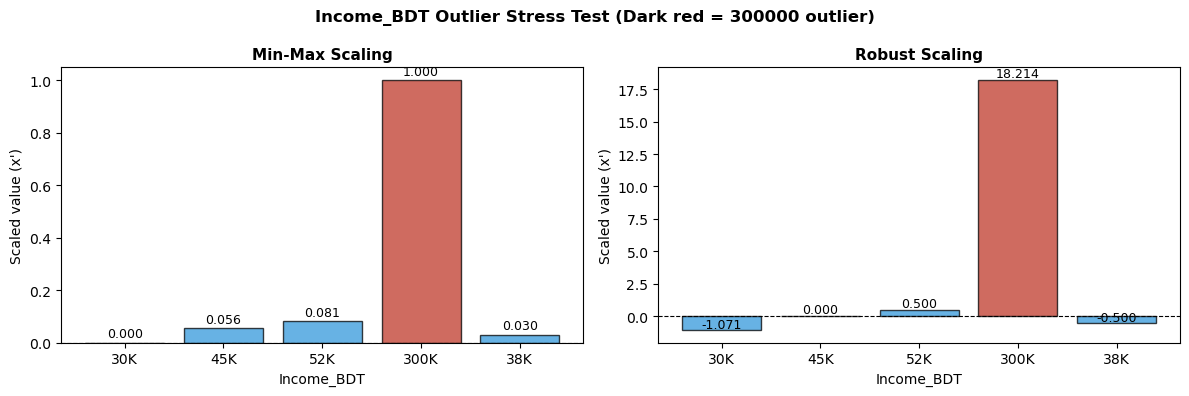

In [7]:
import matplotlib.pyplot as plt

# Now we'll create a side-by-side bar chart for visual comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = [f"{int(v/1000)}K" for v in df['Income_BDT']]
bar_colors = ['#c0392b' if v == 300000 else '#3498db' for v in df['Income_BDT']]

# Here we've set dark red for the outlier bar, blue for normal bars.

for ax, col, title in zip(
    axes,
    ['MinMax_Scaled', 'Robust_Scaled'],
    ['Min-Max Scaling', 'Robust Scaling']
):
    bars = ax.bar(labels, df[col], color=bar_colors, alpha=0.75, edgecolor='black')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('Income_BDT')
    ax.set_ylabel("Scaled value (x')")
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    for bar, val in zip(bars, df[col]):
        ypos = val + 0.01 if val >= 0 else val - 0.08
        ax.text(bar.get_x() + bar.get_width()/2, ypos,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Income_BDT Outlier Stress Test (Dark red = 300000 outlier)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
# Here we've plotted both scalers side by side for direct visual comparison.


**Dark red bar = outlier (300000)।**

Chart-এ স্পষ্ট:
- **Min-Max**: 30K–52K-এর সব bar প্রায় 0 — পার্থক্য বোঝাই যাচ্ছে না।
- **Robust**: normal bar-গুলো কিছুটা আলাদা আলাদা — outlier দূরে কিন্তু আলাদা।


---

## এক লাইনে Comparison Statement

> **Min-Max Scaling-এ 300000 outlier `x_max` হওয়ায় বাকি সব income 0.00–0.08-এর মধ্যে চাপা পড়ে এবং তাদের পার্থক্য প্রায় অদৃশ্য হয়ে যায়, কিন্তু Robust Scaling-এ median ও IQR outlier-এ প্রভাবিত হয় না বলে 30K–52K-এর income-গুলো তাদের relative ব্যবধান বজায় রাখে এবং 300000 শুধু একটি বড় positive value হিসেবে দূরে সরে যায়।**


In [8]:
# Now we'll print a concise final summary
print("=" * 55)
print("     OUTLIER STRESS TEST — FINAL SUMMARY")
print("=" * 55)
print(f"  Outlier value     : 300,000")
print(f"  Normal range      : 30,000 – 52,000")
print()
print(f"  Min-Max:")
print(f"    Outlier scaled  : {df.loc[outlier_idx, 'MinMax_Scaled']:.3f}  (= 1.0, dominates)")
print(f"    Normal spread   : {mm_non_out.min():.3f} to {mm_non_out.max():.3f}  (compressed!)")
print()
print(f"  Robust:")
print(f"    Outlier scaled  : {df.loc[outlier_idx, 'Robust_Scaled']:.3f}  (large but isolated)")
print(f"    Normal spread   : {rob_non_out.min():.3f} to {rob_non_out.max():.3f}  (preserved!)")
print("=" * 55)
# Here we've printed a clean final comparison of both scalers on the outlier.


     OUTLIER STRESS TEST — FINAL SUMMARY
  Outlier value     : 300,000
  Normal range      : 30,000 – 52,000

  Min-Max:
    Outlier scaled  : 1.000  (= 1.0, dominates)
    Normal spread   : 0.000 to 0.081  (compressed!)

  Robust:
    Outlier scaled  : 18.214  (large but isolated)
    Normal spread   : -1.071 to 0.500  (preserved!)


Final summary-তে দুটো scaler-এর পার্থক্য সংখ্যায় স্পষ্ট।

**Stress test-এর verdict:**
- Outlier আছে → **Robust Scaler সর্বদা নিরাপদ**।
- Min-Max outlier-এর কারণে normal data-র তথ্য হারিয়ে ফেলে।


---